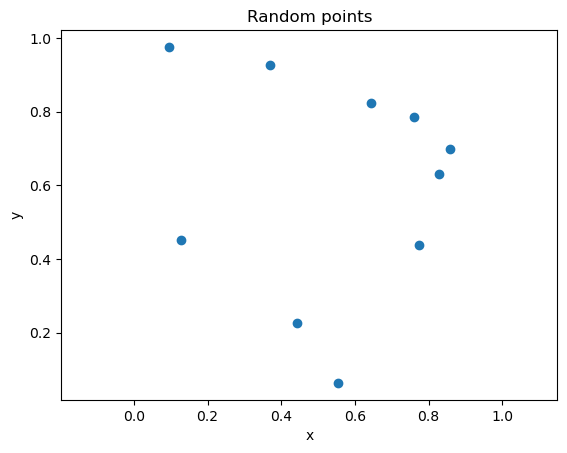

In [2]:
import numpy as np
import matplotlib.pyplot as plt
rng =np.random.default_rng(42)
X =rng.random((10,2))
plt.scatter(X[:,0],X[:,1])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Random points")
plt.axis("equal")
plt.show()

In [3]:
D2 =np.sum((X[:,np.newaxis,:]- X[np.newaxis, :,:]) **2,axis=2)
print(D2)

[[0.         0.07398111 0.75019311 0.12070228 0.41724485 0.40056968
  0.16428994 0.15404928 0.18879464 0.04004745]
 [0.07398111 0.         0.66176428 0.01736513 0.59460745 0.2905717
  0.06183373 0.39339909 0.49381057 0.00527591]
 [0.75019311 0.66176428 0.         0.48077103 0.27702496 0.07890604
  0.32552305 0.68204444 1.04336354 0.65626159]
 [0.12070228 0.01736513 0.48077103 0.         0.51340197 0.17216331
  0.01510002 0.41323553 0.56430573 0.02826045]
 [0.41724485 0.59460745 0.27702496 0.51340197 0.         0.28583271
  0.40466324 0.14920913 0.33131299 0.52218667]
 [0.40056968 0.2905717  0.07890604 0.17216331 0.28583271 0.
  0.08538234 0.49461011 0.77845636 0.29578088]
 [0.16428994 0.06183373 0.32552305 0.01510002 0.40466324 0.08538234
  0.         0.39482809 0.58396752 0.07028811]
 [0.15404928 0.39339909 0.68204444 0.41323553 0.14920913 0.49461011
  0.39482809 0.         0.03906548 0.31118281]
 [0.18879464 0.49381057 1.04336354 0.56430573 0.33131299 0.77845636
  0.58396752 0.039065

In [4]:
differences = X[:,np.newaxis,:] -X[np.newaxis, :, :]
squared_differences = differences ** 2
squared_distances = np.sum(squared_differences, axis=2)
print(differences.shape)
print(squared_differences.shape)
print(squared_distances.shape)

(10, 10, 2)
(10, 10, 2)
(10, 10)


In [5]:
print(np.diag(squared_distances))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [6]:
ordering =np.argsort(squared_distances, axis=1)
print(ordering)
print(ordering[:, 0])

[[0 9 1 3 7 6 8 5 4 2]
 [1 9 3 6 0 5 7 8 4 2]
 [2 5 4 6 3 9 1 7 0 8]
 [3 6 1 9 0 5 7 2 4 8]
 [4 7 2 5 8 6 0 3 9 1]
 [5 2 6 3 4 1 9 0 7 8]
 [6 3 1 9 5 0 2 7 4 8]
 [7 8 4 0 9 1 6 3 5 2]
 [8 7 0 4 9 1 3 6 5 2]
 [9 1 3 0 6 5 7 8 4 2]]
[0 1 2 3 4 5 6 7 8 9]


In [7]:
K = 2
candidates = np.argpartition(squared_distances, K, axis=1)[:, :K + 1]
candidate_distances = np.take_along_axis(squared_distances, candidates, axis=1)
sorted_candidates = np.take_along_axis(
    candidates,
    np.argsort(candidate_distances, axis=1),
    axis=1,)
neighbors = sorted_candidates[:, 1:]
print(neighbors)

[[9 1]
 [9 3]
 [5 4]
 [6 1]
 [7 2]
 [2 6]
 [3 1]
 [8 4]
 [7 0]
 [1 3]]


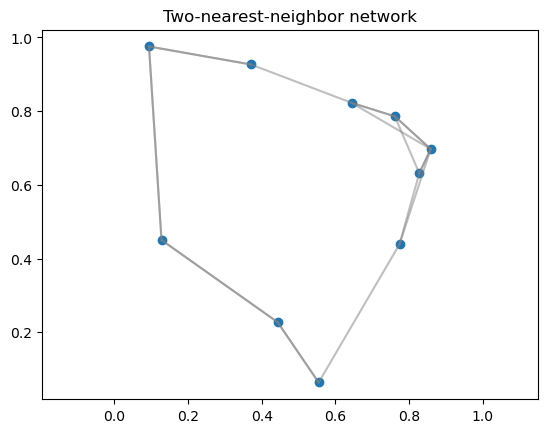

In [9]:
fig, ax =plt.subplots()
ax.scatter(X[:,0],X[:,1],zorder=2)
for i in range(len(X)):
    for j in neighbors[i]:
        ax.plot( [X[i, 0], X[j, 0]],
                 [X[i, 1], X[j, 1]],
            color="gray",
            alpha=0.5,)
ax.set_aspect("equal", adjustable="datalim")
ax.set_title("Two-nearest-neighbor network")
plt.show()

In [13]:
points = np.random.default_rng(1).random((100, 2))
%timeit loop_neighbors(points, 2)
%timeit vectorized_neighbors(points, 2)

1.32 ms ± 97 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
229 μs ± 7.61 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [14]:
points = np.random.default_rng(1).random((1000, 2))
%timeit loop_neighbors(points, 2)
%timeit vectorized_neighbors(points, 2)

59.8 ms ± 4.04 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
44 ms ± 12 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [15]:
points = np.random.default_rng(1).random((5000, 2))
%timeit loop_neighbors(points, 2)
%timeit vectorized_neighbors(points, 2)

1.65 s ± 85 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
1.16 s ± 166 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
